# DECA-FLAME 到 solvePnP 几何可视化

本 Notebook 检查离线深度先验中的两类几何信息：

- 在原图中显示 MediaPipe 检测到的 8 个 `image_points_by_label` 点。
- 在 `224x224` Face 图中显示 DECA 的 `vertices`、`landmarks2d`、`landmarks3d` 与左右眼顶点。
- 在原图中比较检测到的 2D PnP 点与 solvePnP 重投影点，并显示估计眼睛中心的像素投影。

注意：FLAME Layer 的 `landmarks2d` 仍是 FLAME 局部坐标中的动态关键点集合，
不是图像像素坐标。Notebook 使用 DECA 预测的弱透视相机参数，将它投影到 Face 图。
原图上的 2D PnP 点来自基线已保存的 `mediapipe_pnp_landmarks.csv`，坐标为原图像素。

In [1]:
from pathlib import Path
import csv
import random
import sys
from pprint import pprint

import cv2
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from PIL import Image


def find_project_root():
    here = Path.cwd().resolve()
    for candidate in (here, *here.parents):
        if (candidate / 'data' / 'processed' / 'modelv1_dataset.csv').is_file():
            return candidate
    raise FileNotFoundError('Cannot find data/processed/modelv1_dataset.csv.')


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
CSV_PATH = PROJECT_ROOT / 'data' / 'processed' / 'modelv1_dataset.csv'

with CSV_PATH.open('r', encoding='utf-8-sig', newline='') as handle:
    rows = list(csv.DictReader(handle))

print('Project root:', PROJECT_ROOT)
print('Dataset CSV:', CSV_PATH)
print('Sample count:', len(rows))
print('Datasets:', sorted({row['dataset'] for row in rows}))

Project root: D:\GithubCode\ModelV1
Dataset CSV: D:\GithubCode\ModelV1\data\processed\modelv1_dataset.csv
Sample count: 1133
Datasets: ['dataset_dual_rigid_body_3', 'dataset_dual_rigid_body_4', 'dataset_dual_rigid_body_5']


## 选择样本

将 `SAMPLE_INDEX` 设为整数可固定检查某一条记录；保持为 `None` 时随机选择。
`DATASET_FILTER` 可以是完整数据集名，例如 `dataset_dual_rigid_body_3`。

In [2]:
DATASET_FILTER = None
SAMPLE_INDEX = 99
RANDOM_SEED = 42
RUN_DECA = True
FACE_PREPROCESS = 'deca'
DECA_CROP_SCALE = 1.25


def choose_sample(all_rows, dataset_filter, sample_index, random_seed):
    candidates = [
        row for row in all_rows
        if dataset_filter is None or row['dataset'] == dataset_filter
    ]
    if not candidates:
        raise ValueError(f'No rows found for DATASET_FILTER={dataset_filter!r}.')
    if sample_index is None:
        random.seed(random_seed)
        return random.choice(candidates)
    return candidates[sample_index]


sample = choose_sample(rows, DATASET_FILTER, SAMPLE_INDEX, RANDOM_SEED)
pprint({
    'sample_id': sample['sample_id'],
    'dataset': sample['dataset'],
    'image_name': sample['image_name'],
    'source_image_path': sample['source_image_path'],
    'face_path': sample['face_path'],
    'pnp_status': sample['pnp_status'],
})

{'dataset': 'dataset_dual_rigid_body_3',
 'face_path': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_3\\insightface_face\\img_20260422_151823_00117.jpg',
 'image_name': 'img_20260422_151823_00117.jpg',
 'pnp_status': 'success',
 'sample_id': 'dataset_dual_rigid_body_3/img_20260422_151823_00117',
 'source_image_path': 'D:\\GithubCode\\CrossGaze-main\\baseline\\data_collection\\dataset_dual_rigid_body_3\\insightface_img\\img_20260422_151823_00117.jpg'}


## 读取 8 个 PnP 2D 检测点

基线已经将 MediaPipe Face Mesh 的检测结果保存在每个采集目录下的
`mediapipe_pnp_landmarks.csv`。这里直接读取该文件，以保证显示的点与离线 PnP
使用的原图像素坐标一致。

In [3]:
PNP_LANDMARKS = (
    ('left_eye_outer', 33),
    ('left_eye_inner', 133),
    ('right_eye_inner', 362),
    ('right_eye_outer', 263),
    ('nose_tip', 1),
    ('mouth_left', 61),
    ('mouth_right', 291),
    ('chin', 152),
)
FLAME_PNP_INDEX_BY_LABEL = {
    'left_eye_outer': 36,
    'left_eye_inner': 39,
    'right_eye_inner': 42,
    'right_eye_outer': 45,
    'nose_tip': 30,
    'mouth_left': 48,
    'mouth_right': 54,
    'chin': 8,
}


def load_saved_pnp_points(row):
    landmark_csv = Path(row['source_dataset_dir']) / 'mediapipe_pnp_landmarks.csv'
    if not landmark_csv.is_file():
        raise FileNotFoundError(
            'Saved MediaPipe PnP landmarks were not found: ' + str(landmark_csv)
        )
    with landmark_csv.open('r', encoding='utf-8-sig', newline='') as handle:
        for landmark_row in csv.DictReader(handle):
            if landmark_row['image_name'] != row['image_name']:
                continue
            if landmark_row.get('status') != 'success':
                raise RuntimeError(
                    'MediaPipe detection failed for this sample: ' + landmark_row.get('reason', '')
                )
            points = {}
            for label, _ in PNP_LANDMARKS:
                points[label] = (
                    float(landmark_row[f'{label}_x']),
                    float(landmark_row[f'{label}_y']),
                )
            return points, landmark_csv
    raise KeyError(f"No PnP landmark row for {row['image_name']!r}.")


pnp_points, PNP_CSV_PATH = load_saved_pnp_points(sample)
print('PnP landmark CSV:', PNP_CSV_PATH)
pprint(pnp_points)

PnP landmark CSV: D:\GithubCode\CrossGaze-main\baseline\data_collection\dataset_dual_rigid_body_3\mediapipe_pnp_landmarks.csv
{'chin': (988.816, 519.451),
 'left_eye_inner': (946.362, 310.197),
 'left_eye_outer': (896.281, 308.461),
 'mouth_left': (938.766, 442.608),
 'mouth_right': (1028.889, 437.862),
 'nose_tip': (992.034, 377.812),
 'right_eye_inner': (1013.163, 309.416),
 'right_eye_outer': (1057.407, 305.981)}


## 在原图显示人脸框和 PnP 2D 检测结构

圆点与文字标签是 `image_points_by_label`。这些是送入 solvePnP 的二维像素点。

DECA preprocessing: deca
DECA input image shape: (224, 224, 3)
DECA source crop [left, top, width, height]: (773.5, 182.45999999999998, 385.0, 385.0)
Unresized detector-face crop shape: (362, 254, 3)


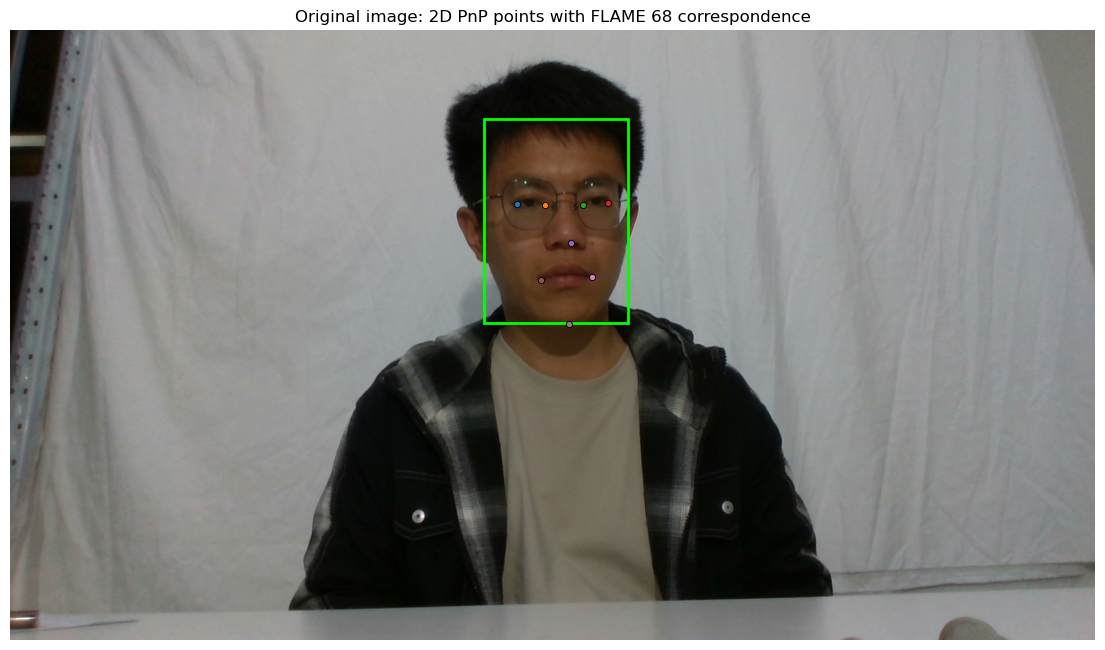

In [4]:
source_image = np.asarray(Image.open(sample['source_image_path']).convert('RGB'))
legacy_face_image = np.asarray(Image.open(sample['face_path']).convert('RGB'))

face_bbox = tuple(float(sample[f'face_bbox_{key}']) for key in ('x', 'y', 'w', 'h'))

from modelv1.depth_prior import prepare_deca_face_image

deca_input_face_image, deca_crop_transform = prepare_deca_face_image(
    source_image,
    face_bbox,
    mode=FACE_PREPROCESS,
    input_size=224,
    deca_crop_scale=DECA_CROP_SCALE,
    legacy_face_image_rgb=legacy_face_image,
)


def crop_detected_face(image, bbox_xywh):
    """Crop the original image using the detector bbox without resizing."""
    x, y, width, height = bbox_xywh
    image_height, image_width = image.shape[:2]
    x0 = max(0, min(image_width, int(np.floor(x))))
    y0 = max(0, min(image_height, int(np.floor(y))))
    x1 = max(x0 + 1, min(image_width, int(np.ceil(x + width))))
    y1 = max(y0 + 1, min(image_height, int(np.ceil(y + height))))
    return image[y0:y1, x0:x1], (x0, y0, x1, y1)


face_bbox_image, face_bbox_xyxy = crop_detected_face(source_image, face_bbox)
print('DECA preprocessing:', FACE_PREPROCESS)
print('DECA input image shape:', deca_input_face_image.shape)
print('DECA source crop [left, top, width, height]:', (
    deca_crop_transform.source_left_px, deca_crop_transform.source_top_px,
    deca_crop_transform.source_width_px, deca_crop_transform.source_height_px,
))
print('Unresized detector-face crop shape:', face_bbox_image.shape)

fig, ax = plt.subplots(figsize=(14, 8))
ax.imshow(source_image)
ax.add_patch(Rectangle(face_bbox[:2], face_bbox[2], face_bbox[3], fill=False, linewidth=2, edgecolor='lime'))
for index, (label, point) in enumerate(pnp_points.items()):
    color = plt.cm.tab10(index % 10)
    ax.scatter(*point, s=20, color=color, edgecolor='black', linewidth=0.6, zorder=1)
    annotation = f"{label}\nFLAME[{FLAME_PNP_INDEX_BY_LABEL[label]}]"
    # ax.annotate(annotation, point, xytext=(5, -8), textcoords='offset points', color='white', fontsize=9,
    #             bbox={'facecolor': 'black', 'alpha': 0.6, 'pad': 1.5})
ax.set_title('Original image: 2D PnP points with FLAME 68 correspondence')
ax.set_axis_off()
plt.show()

## 运行 DECA-FLAME

这一格调用项目新增的 `DecaFlameExtractor`。它使用官方 DECA 的编码器和
FLAME Layer。若当前环境尚未安装 `yacs` 或 DECA 的其他依赖，Notebook 会保留
前面的原图检测可视化，并显示缺失依赖，而不会继续执行 PnP。

In [5]:
deca_output = None
deca_error = None

if RUN_DECA:
    try:
        import torch
        from modelv1.depth_prior import DecaFlameExtractor

        face_tensor = torch.from_numpy(deca_input_face_image.copy()).permute(2, 0, 1).float() / 255.0
        face_tensor = face_tensor.unsqueeze(0)
        deca = DecaFlameExtractor()
        deca_output = deca.extract(face_tensor)
        print('DECA output shapes:')
        print('  vertices:', tuple(deca_output.vertices.shape))
        print('  landmarks2d:', tuple(deca_output.landmarks2d.shape))
        print('  landmarks3d:', tuple(deca_output.landmarks3d.shape))
        print('  left_eye_vertex:', tuple(deca_output.left_eye_vertex.shape))
        print('  right_eye_vertex:', tuple(deca_output.right_eye_vertex.shape))
    except Exception as error:
        deca_error = error
        print('DECA-FLAME has not run:', type(error).__name__, error)
        print('Install the official DECA runtime dependencies, then rerun this cell.')
else:
    print('RUN_DECA is False: skip DECA-FLAME extraction.')

d:\software\Anaconda\envs\3DGazeNet\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
d:\software\Anaconda\envs\3DGazeNet\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


creating the FLAME Decoder
DECA output shapes:
  vertices: (1, 5023, 3)
  landmarks2d: (1, 68, 3)
  landmarks3d: (1, 68, 3)
  left_eye_vertex: (1, 3)
  right_eye_vertex: (1, 3)


## 在 Face 图和 FLAME 局部三维坐标中显示 DECA 输出

左图直接显示原图坐标，不显示 resize 后的 DECA 输入。默认 `FACE_PREPROCESS='deca'`
时，视野是官方风格的正方形 DECA 裁剪区域；绿色框仍是原始人脸检测框。DECA 的
弱透视投影会通过同一裁剪变换还原至原图。灰点为抽样网格顶点，橙点为
`landmarks2d`，青点为 `landmarks3d`，红蓝星形点为双眼内外眼角中点。
右图显示相同点在 FLAME 局部坐标系中的三维结构。

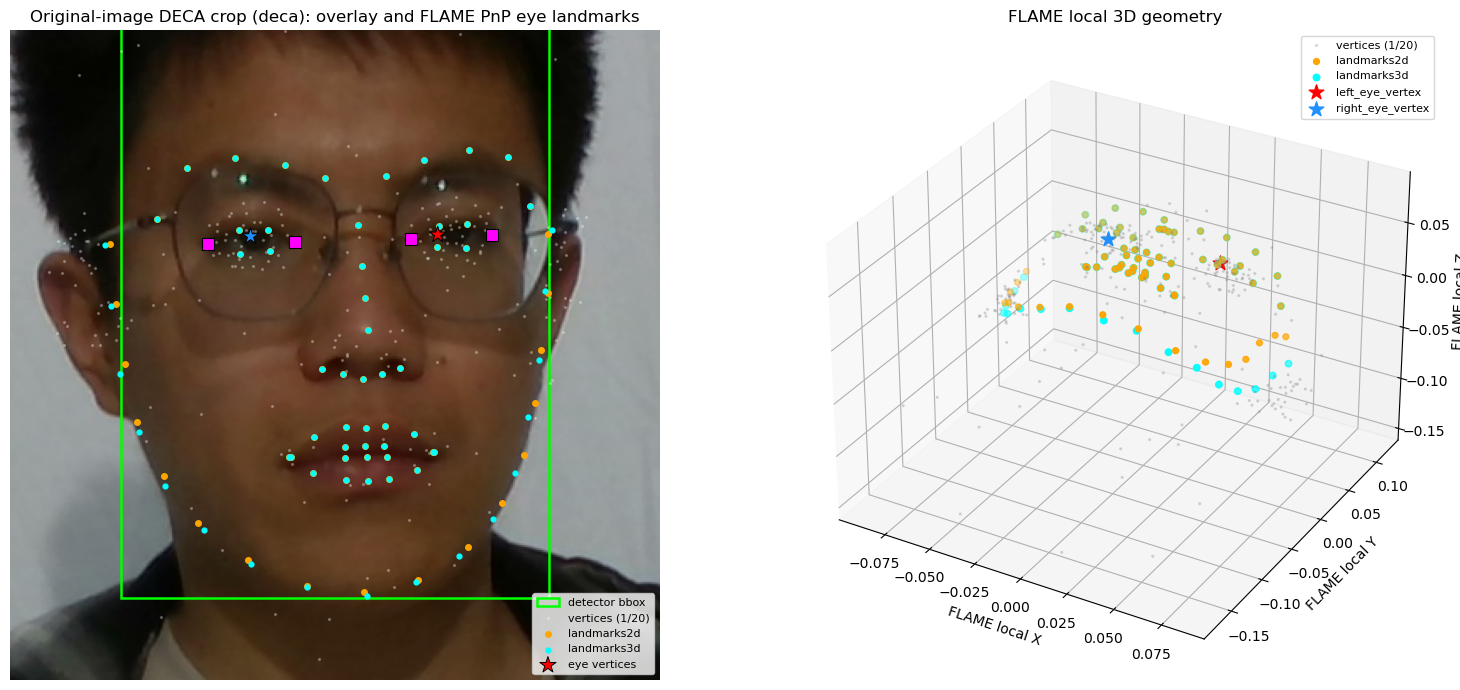

In [6]:
def project_deca_local_points_to_input(points_xyz, weak_perspective_camera, input_size):
    """Match DECA decode(): weak-perspective projection followed by y flip."""
    points = np.asarray(points_xyz, dtype=np.float64)
    scale, tx, ty = np.asarray(weak_perspective_camera, dtype=np.float64)
    normalized_xy = scale * (points[:, :2] + np.array([tx, ty]))
    normalized_xy[:, 1] *= -1.0
    pixels = np.empty_like(normalized_xy)
    pixels[:, 0] = (normalized_xy[:, 0] + 1.0) * input_size / 2.0
    pixels[:, 1] = (normalized_xy[:, 1] + 1.0) * input_size / 2.0
    return pixels


if deca_output is None:
    print('Skip DECA visualizations until the DECA dependency error above is resolved.')
else:
    # DECA parameter layout: shape[0:100], tex[100:150], exp[150:200],
    # pose[200:206], cam[206:209], light[209:236].
    weak_camera = deca_output.parameters[0, 206:209].numpy()
    vertices = deca_output.vertices[0].numpy()
    landmarks2d = deca_output.landmarks2d[0].numpy()
    landmarks3d = deca_output.landmarks3d[0].numpy()
    left_eye_canthus_midpoint = 0.5 * (landmarks3d[36] + landmarks3d[39])
    right_eye_canthus_midpoint = 0.5 * (landmarks3d[42] + landmarks3d[45])

    # Project into DECA input pixels, then invert the exact preprocessing crop
    # so the overlay remains in original-image coordinates.
    vertices_input_pixels = project_deca_local_points_to_input(
        vertices, weak_camera, deca_crop_transform.input_size
    )
    landmarks2d_input_pixels = project_deca_local_points_to_input(
        landmarks2d, weak_camera, deca_crop_transform.input_size
    )
    landmarks3d_input_pixels = project_deca_local_points_to_input(
        landmarks3d, weak_camera, deca_crop_transform.input_size
    )
    eye_reference_input_pixels = project_deca_local_points_to_input(
        np.stack([left_eye_canthus_midpoint, right_eye_canthus_midpoint]),
        weak_camera,
        deca_crop_transform.input_size,
    )
    vertices_pixels = deca_crop_transform.input_pixels_to_source(vertices_input_pixels)
    landmarks2d_pixels = deca_crop_transform.input_pixels_to_source(landmarks2d_input_pixels)
    landmarks3d_pixels = deca_crop_transform.input_pixels_to_source(landmarks3d_input_pixels)
    eye_reference_pixels = deca_crop_transform.input_pixels_to_source(eye_reference_input_pixels)

    fig = plt.figure(figsize=(16, 7))
    ax_face = fig.add_subplot(1, 2, 1)
    ax_face.imshow(source_image)
    ax_face.add_patch(Rectangle(face_bbox[:2], face_bbox[2], face_bbox[3], fill=False, linewidth=1.8, edgecolor='lime', label='detector bbox'))
    ax_face.set_xlim(deca_crop_transform.source_left_px, deca_crop_transform.source_right_px)
    ax_face.set_ylim(deca_crop_transform.source_bottom_px, deca_crop_transform.source_top_px)
    ax_face.scatter(vertices_pixels[::20, 0], vertices_pixels[::20, 1], s=2, color='white', alpha=0.24, label='vertices (1/20)')
    ax_face.scatter(landmarks2d_pixels[:, 0], landmarks2d_pixels[:, 1], s=16, color='orange', label='landmarks2d')
    ax_face.scatter(landmarks3d_pixels[:, 0], landmarks3d_pixels[:, 1], s=12, color='cyan', label='landmarks3d')
    eye_pnp_labels = ('left_eye_outer', 'left_eye_inner', 'right_eye_inner', 'right_eye_outer')
    for label in eye_pnp_labels:
        flame_index = FLAME_PNP_INDEX_BY_LABEL[label]
        point = landmarks3d_pixels[flame_index]
        ax_face.scatter(*point, s=70, marker='s', color='magenta', edgecolor='black', linewidth=0.8, zorder=5)
        # ax_face.annotate(f"{label}\nFLAME[{flame_index}]", point, xytext=(5, -10), textcoords='offset points',
        #                  color='white', fontsize=8, bbox={'facecolor': 'black', 'alpha': 0.65, 'pad': 1.2})
    ax_face.scatter(eye_reference_pixels[:, 0], eye_reference_pixels[:, 1], s=150, marker='*', c=['red', 'dodgerblue'], edgecolor='black', linewidth=0.7, label='eye-canthus midpoints')
    ax_face.set_title(f'Original-image DECA crop ({FACE_PREPROCESS}): overlay and FLAME PnP eye landmarks')
    ax_face.set_axis_off()
    ax_face.legend(loc='lower right', fontsize=8)

    ax_3d = fig.add_subplot(1, 2, 2, projection='3d')
    ax_3d.scatter(vertices[::20, 0], vertices[::20, 1], vertices[::20, 2], s=2, color='gray', alpha=0.22, label='vertices (1/20)')
    ax_3d.scatter(landmarks2d[:, 0], landmarks2d[:, 1], landmarks2d[:, 2], s=18, color='orange', label='landmarks2d')
    ax_3d.scatter(landmarks3d[:, 0], landmarks3d[:, 1], landmarks3d[:, 2], s=22, color='cyan', label='landmarks3d')
    ax_3d.scatter(*left_eye_canthus_midpoint, s=120, marker='*', color='red', label='left eye-canthus midpoint')
    ax_3d.scatter(*right_eye_canthus_midpoint, s=120, marker='*', color='dodgerblue', label='right eye-canthus midpoint')
    ax_3d.set_xlabel('FLAME local X')
    ax_3d.set_ylabel('FLAME local Y')
    ax_3d.set_zlabel('FLAME local Z')
    ax_3d.set_title('FLAME local 3D geometry')
    ax_3d.legend(loc='upper right', fontsize=8)
    plt.tight_layout()
    plt.show()

## 求解 PnP 并查看相机坐标输出

此处将原图中的 `image_points_by_label`、DECA 的 `landmarks3d` / `vertices`
及基线相机标定参数送入 `solve_pnp_face_depth`。输出中的双眼中心为相机坐标系下的毫米值。

In [7]:
pnp_result = None
camera = None

if deca_output is None:
    print('Skip solvePnP because DECA geometry is unavailable.')
else:
    from modelv1.depth_prior import PnpCamera, solve_pnp_face_depth

    camera = PnpCamera.crossgaze_default()
    pnp_result = solve_pnp_face_depth(
        image_points_by_label=pnp_points,
        landmarks3d=landmarks3d,
        camera=camera,
    )
    pprint(pnp_result.as_record())

TypeError: solve_pnp_face_depth() got an unexpected keyword argument 'vertices'

## 在原图检查 solvePnP 重投影

圆点是检测到的二维点，黄色叉号是 solvePnP 将对应的 FLAME 三维点重新投影后的结果。
两者之间的连线越短，说明 PnP 拟合越好。红蓝星形点是估计出的左右眼中心投影。

In [ ]:
if pnp_result is None:
    print('Skip reprojection visualization because solvePnP did not run.')
else:
    from modelv1.depth_prior import DEFAULT_PNP_MAPPING

    flame_indices = [item.flame_landmark_index for item in DEFAULT_PNP_MAPPING]
    labels = [item.label for item in DEFAULT_PNP_MAPPING]
    object_points_mm = landmarks3d[flame_indices] * pnp_result.scale.scale_mm_per_flame_unit
    reprojected, _ = cv2.projectPoints(
        object_points_mm,
        pnp_result.rvec.reshape(3, 1),
        pnp_result.tvec_mm.reshape(3, 1),
        camera.camera_matrix,
        camera.dist_coeffs,
    )
    reprojected = reprojected.reshape(-1, 2)

    eye_camera_xyz = np.stack([
        pnp_result.left_eye_camera_xyz_mm,
        pnp_result.right_eye_camera_xyz_mm,
    ])
    eye_pixels, _ = cv2.projectPoints(
        eye_camera_xyz,
        np.zeros((3, 1)),
        np.zeros((3, 1)),
        camera.camera_matrix,
        camera.dist_coeffs,
    )
    eye_pixels = eye_pixels.reshape(-1, 2)

    fig, ax = plt.subplots(figsize=(14, 8))
    ax.imshow(source_image)
    for index, (label, detected, projected) in enumerate(zip(labels, [pnp_points[label] for label in labels], reprojected)):
        color = plt.cm.tab10(index % 10)
        ax.scatter(*detected, s=55, color=color, edgecolor='black', linewidth=0.6, zorder=3)
        ax.scatter(*projected, s=68, marker='x', color='yellow', linewidth=2, zorder=4)
        ax.plot([detected[0], projected[0]], [detected[1], projected[1]], color=color, linewidth=1.2, alpha=0.9)
        annotation = f"{label}\nFLAME[{FLAME_PNP_INDEX_BY_LABEL[label]}]"
        ax.annotate(annotation, detected, xytext=(5, -8), textcoords='offset points', color='white', fontsize=8,
                    bbox={'facecolor': 'black', 'alpha': 0.55, 'pad': 1.2})
    ax.scatter(*eye_pixels[0], s=180, marker='*', color='red', edgecolor='black', linewidth=0.7, label='left_canthus_midpoint_camera')
    ax.scatter(*eye_pixels[1], s=180, marker='*', color='dodgerblue', edgecolor='black', linewidth=0.7, label='right_canthus_midpoint_camera')
    ax.plot([], [], 'o', color='gray', label='detected 2D point')
    ax.plot([], [], 'x', color='yellow', label='PnP reprojection')
    ax.legend(loc='lower right')
    ax.set_title(
        f"PnP reprojection: mean={pnp_result.reprojection_error_mean_px:.2f}px, "
        f"max={pnp_result.reprojection_error_max_px:.2f}px, "
        f"depth={pnp_result.face_depth_z_mm:.1f}mm"
    )
    ax.set_axis_off()
    plt.show()

## 如何解读结果

- 原图检测图用于检查 `image_points_by_label` 是否落在正确的解剖位置。
- Face 图 DECA 叠加用于检查 DECA 的弱透视投影与对齐人脸图是否匹配。
- FLAME 局部三维图用于确认 `vertices`、`landmarks2d`、`landmarks3d` 和眼睛顶点的相对位置。
- 最后一张重投影图用于检查 2D-3D 对应关系、相机内参和尺度是否一致。若连线明显变长，
  应优先检查 2D 点标签、FLAME 68 点索引、相机标定参数与 `scale_mm_per_flame_unit`。

原图与 Face 图是不同坐标系：本 Notebook 不把原图 PnP 点强行映射到 Face 图，
以避免把 InsightFace 对齐变换误当作简单的 bbox 缩放。